# Challenge 1: Geodemographic Classification

In this challenge, you will replicate the process of creating a geodemographic classification using the k-means clustering algorithm. Please select any city in the UK except London, Liverpool, or Glasgow. The main goal is to generate a meaningful and informative classification that captures the diversity of areas in your dataset using the census data ( For England, you can try to use the 2021 or 2011 census, and for Scotland, you need to use the 2011 census data) 

1. Define the main goal for the geodemographic classification (marketing, retail and service planning). 
2. Look for census data from the selected city for which you would like to generate the geodemographic classification.
3. The census data at the Output Area OA level. Select multiple topics of at least four topics (socio-demographics, economics, health, and so on). Describe your topic selection accordingly based on the goal of your geodemographic classification. For example, if your geodemographics are related to marketing, Economic variables might be the appropriate selection. 
4. Identify the variables that will be crucial for effectively segmenting neighbourhoods. Evaluate how this choice may impact the classification results, including a DEA analysis.
5. Prepare, adjust or clean the dataset addressing any missing values or outliers that could distort the clustering results.
6. Include standardisation between areas and variables. Make an appropriate analysis and adjust the variable selection accordingly for any multicollinearity.
7. Utilize the k-means clustering algorithm to create a classification based on the selected variables.
8. Define the optimum number of clusters (i.e., using the Elblow method). Experiment with different values of k.
9. Evaluate your cluster groups (e.g., using PCA) and interpret your cluster centres. Describe your results and repeat the process to adjust the variable selection and cluster groups to provide more meaningful results for your geodemographic goal. Interpret the characteristics of each cluster. What demographic patterns or similarities are prevalent within each group?
10. Map the final cluster groups
11. Finish the analysis by naming the final clusters and plotting a final map that includes the census values and the provided names.
12. Finally, acknowledge the subjective nature of classification and make analytical decisions to produce an optimum classification for your specific purpose. Reflect on the challenges and insights gained during the classification process. Ensure you document your analytical decisions and the rationale behind any important decision. Once your geodemographics are constructed, describe the potential use cases for the geodemographic classification you have built based on your initial goal.

In [ ]:
#defining the main goal for the geodemographic classification

I will be examining data for the city of Brigthton and Hove from a marketing perspective using data from the 2021 Census for England and Wales.

**Study area**: Brighton and Hove
**Geography (spatial units)** Output Areas 
**Dataset**: 2021 United Kingdom Census 

**Census Variables Used** - 
- Age structure
- Economic activity
- Ethnicity
- General Health
- Highest Level of Educational Qualification
- Industry
- Living Arrangement
- Marital and civil partnership status
- Religion
- Sex

Reference: ONS (2021). Census - Office for National Statistics. [online] Ons.gov.uk. Available at: https://www.ons.gov.uk/census.

<u>Introduction<u>

I have chosen to investigate the city of Brighton and Hove since census data available at the granular level illuminates the demographic and socio-economic composition of different localities (Forster and Burgess, 2024), which indicates diverse consumer needs and purchasing power. Brighton and Hove display significant micro-geographic variations in terms of affluence and deprivation (Broome-Smith, 2010).  Smith (2023) provides  a choropleth map of Brighton and Hove that shows visually the clear economic disparities across the small city and Foster and Burgess’ (2024) work examining the segregation of residential spaces notes that residential differences can be identified by neighbourhood characteristics that may influence consumer behaviour. Indices of Deprivation, reported at the output level (Broome-Smith, 2010), provide valuable insights into the uneven levels of deprivation and income across Brighton (Broome-Smith, 2010). Therefore, a marketing investigation, facilitated by geographic data and GIS, would enable marketing teams to move beyond broad city-level campaigns but instead tailor their messaging to the specific economic realities and needs of individual output areas (Broome-Smith, 2010). The level of granularity provided through examining the city through the Output Areas level would enhance the effectiveness of marketing efforts by ensuring relevance and resonance with the target audience in each distinct locality.

References and inspirations for the investigation: 

- Broome-Smith, J. (2010). CHILDHOOD DISABILITY IN BRIGHTON AND HOVE: A GEOGRAPHIC PERSPECTIVE.

- Forster, C.M. and Burgess, O. (2024). The Student City: Residential Segregation in Brighton and Hove. Bristol Institute for Learning and Teaching (BILT) Student Research Journal, 5.

- Hall, C., Davies, J.K. and Sherriff, N. (2009). Health in the Urban Environment: A Qualitative Review of the Brighton and Hove WHO Healthy City Program. Journal of Urban Health, 87(1), pp.8–28. doi:https://doi.org/10.1007/s11524-009-9387-y.

- Mazzilli, C. (2020). ‘The happiest city in England’ Brighton’s narratives of diversity between ‘success stories’ and sidelined issues. Ethnic and Racial Studies, 44(11), pp.2074–2092. doi:https://doi.org/10.1080/01419870.2020.1823449.

- Smith, M. (2023). Trans infrastructures: experiences of liveability in Brighton & Hove and implications for urban planning.



In [ ]:
#identifying variables to help with a marketing analysis 

In [ ]:
#preparing the variables for analysis

In [3]:
#exploring one variable for analysis - ethnicity to look at how the columns are
import pandas as pd
import geopandas as gpd
age_directory = "data/lab_raw_data/agebrighton.csv"
age = gpd.read_file(age_directory)
age.head()

,Output Areas,Age (6 categories) Code,Age (6 categories),Observation Age
0,E00085001,1,Aged 15 years and under,13
1,E00085001,2,Aged 16 to 24 years,37
2,E00085001,3,Aged 25 to 34 years,58
3,E00085001,4,Aged 35 to 49 years,71
4,E00085001,5,Aged 50 to 64 years,40


In [4]:
#reading in selected raw census data (csv files)
import pandas as pd
import os

csv_directory = "data/lab_raw_data"

csv_files = [file for file in os.listdir(csv_directory) if file.endswith(".csv")]

# an empty DataFrame to store the merged data
merged_data = pd.DataFrame()

In [5]:
#merging the csv files
for csv_file in csv_files:
    csv_path = os.path.join(csv_directory, csv_file)
    df_csv = pd.read_csv(csv_path, low_memory=False)
    merged_data = pd.concat([merged_data, df_csv], axis=1)

merged_data.to_csv("data/lab_raw_data/merged_lab_data.csv", index=False)

In [6]:
#checking out first few columns of merged variables
merged_data.head()

,Output Areas,Age (6 categories) Code,Age (6 categories),Observation Age,OA,Age,Age_Obs,Economic_status,Economic_Obs,Ethnic_group,...,Observation Living arrangements,Marital and civil partnership status (6 categories) Code,Marital and civil partnership status (6 categories),Observation Marital and civil partnership status,Religion (10 categories) Code,Religion (10 categories),Observation Religion,Sex (2 categories) Code,Sex (2 categories),Observation Sex
0,E00085001,1.0,Aged 15 years and under,13.0,E00085001,Aged 15 years and under,13.0,Does not apply,13.0,Does not apply,...,13.0,-8.0,Does not apply,13.0,-8.0,Does not apply,0.0,1.0,Female,118.0
1,E00085001,2.0,Aged 16 to 24 years,37.0,E00085001,Aged 16 to 24 years,37.0,Economically active (excluding full-time stude...,133.0,"Asian, Asian British or Asian Welsh: Bangladeshi",...,40.0,1.0,Never married and never registered a civil par...,145.0,1.0,No religion,127.0,2.0,Male,121.0
2,E00085001,3.0,Aged 25 to 34 years,58.0,E00085001,Aged 25 to 34 years,58.0,Economically active (excluding full-time stude...,7.0,"Asian, Asian British or Asian Welsh: Chinese",...,4.0,2.0,Married or in a registered civil partnership,44.0,2.0,Christian,59.0,1.0,Female,181.0
3,E00085001,4.0,Aged 35 to 49 years,71.0,E00085001,Aged 35 to 49 years,71.0,Economically active and a full-time student: I...,10.0,"Asian, Asian British or Asian Welsh: Indian",...,0.0,3.0,"Separated, but still legally married or still ...",8.0,3.0,Buddhist,1.0,2.0,Male,145.0
4,E00085001,5.0,Aged 50 to 64 years,40.0,E00085001,Aged 50 to 64 years,40.0,Economically active and a full-time student: U...,7.0,"Asian, Asian British or Asian Welsh: Pakistani",...,36.0,4.0,Divorced or civil partnership dissolved,26.0,4.0,Hindu,3.0,1.0,Female,123.0


In [11]:
#renaming categories so that data manipulation is easier
short_column_names = {
    'Output Areas': 'OA',
    'Age (6 categories)': 'Age',
    'Observation Age': 'Age_O',
    'Economic activity status (7 categories)': 'Econ_st',
    'Observation Economic activity status': 'Econ_O',
    'Ethnic group (20 categories)': 'Ethnc_grp',
    'Observation Ethnic group': 'Ethnc_O',
    'General health (4 categories)': 'Hlth',
    'Observation General health': 'Hlth_O',
    'Highest level of qualification (7 categories)': 'Hghst_q',
    'Observation Highest level of qualification': 'Hghst_O',
    'Industry (current) (9 categories)': 'Indst',
    'Observation Industry (current)': 'Indst_O',
    'Living arrangements (11 categories)': 'Lvng_ar',
    'Observation Living arrangements': 'Lvng_O',
    'Marital and civil partnership status (6 categories)': 'Mrtl_st',
    'Observation Marital and civil partnership status': 'Mrtl_O',
    'Religion (10 categories)': 'Rlgn',
    'Observation Religion': 'Rlgn_O',
    'Sex (2 categories)': 'Sex',
    'Observation Sex': 'Sex_O'
}

brighton_census_data = merged_data.rename(columns=short_column_names)

In [12]:
#reviewing new names of columns
brighton_census_data.head()

,OA,Age (6 categories) Code,Age,Age_O,OA,Age,Age_Obs,Economic_status,Economic_Obs,Ethnic_group,...,Lvng_O,Marital and civil partnership status (6 categories) Code,Mrtl_st,Mrtl_O,Religion (10 categories) Code,Rlgn,Rlgn_O,Sex (2 categories) Code,Sex,Sex_O
0,E00085001,1.0,Aged 15 years and under,13.0,E00085001,Aged 15 years and under,13.0,Does not apply,13.0,Does not apply,...,13.0,-8.0,Does not apply,13.0,-8.0,Does not apply,0.0,1.0,Female,118.0
1,E00085001,2.0,Aged 16 to 24 years,37.0,E00085001,Aged 16 to 24 years,37.0,Economically active (excluding full-time stude...,133.0,"Asian, Asian British or Asian Welsh: Bangladeshi",...,40.0,1.0,Never married and never registered a civil par...,145.0,1.0,No religion,127.0,2.0,Male,121.0
2,E00085001,3.0,Aged 25 to 34 years,58.0,E00085001,Aged 25 to 34 years,58.0,Economically active (excluding full-time stude...,7.0,"Asian, Asian British or Asian Welsh: Chinese",...,4.0,2.0,Married or in a registered civil partnership,44.0,2.0,Christian,59.0,1.0,Female,181.0
3,E00085001,4.0,Aged 35 to 49 years,71.0,E00085001,Aged 35 to 49 years,71.0,Economically active and a full-time student: I...,10.0,"Asian, Asian British or Asian Welsh: Indian",...,0.0,3.0,"Separated, but still legally married or still ...",8.0,3.0,Buddhist,1.0,2.0,Male,145.0
4,E00085001,5.0,Aged 50 to 64 years,40.0,E00085001,Aged 50 to 64 years,40.0,Economically active and a full-time student: U...,7.0,"Asian, Asian British or Asian Welsh: Pakistani",...,36.0,4.0,Divorced or civil partnership dissolved,26.0,4.0,Hindu,3.0,1.0,Female,123.0


In [13]:
#cleaning up the merged variables dataset for better visibility during data analysis - clearing out irrelevant columns
keep_cols= [
    'OA',
    'Age',
    'Age_O',
    'Econ_st',
    'Econ_O',
    'Ethnc_grp',
    'Ethnc_O',
    'Hlth',
    'Hlth_O',
    'Hghst_q',
    'Hghst_O',
    'Indst',
    'Indst_O',
    'Lvng_ar',
    'Lvng_O',
    'Mrtl_st',
    'Mrtl_O',
    'Rlgn',
    'Rlgn_O',
    'Sex',
    'Sex_O'
]
    
brighton_census_data = brighton_census_data[keep_cols]

In [14]:
#checking the new table
brighton_census_data.head()

,OA,OA,Age,Age,Age_O,Econ_st,Econ_O,Ethnc_grp,Ethnc_O,Hlth,...,Indst_O,Lvng_ar,Lvng_O,Mrtl_st,Mrtl_O,Rlgn,Rlgn_O,Sex,Sex,Sex_O
0,E00085001,E00085001,Aged 15 years and under,Aged 15 years and under,13.0,Does not apply,13.0,Does not apply,0,Does not apply,...,96.0,Does not apply,13.0,Does not apply,13.0,Does not apply,0.0,Female,Female,118.0
1,E00085001,E00085001,Aged 16 to 24 years,Aged 16 to 24 years,37.0,Economically active (excluding full-time stude...,133.0,"Asian, Asian British or Asian Welsh: Bangladeshi",0,Very good or good health,...,1.0,Living in an opposite-sex couple: Married or i...,40.0,Never married and never registered a civil par...,145.0,No religion,127.0,Male,Male,121.0
2,E00085001,E00085001,Aged 25 to 34 years,Aged 25 to 34 years,58.0,Economically active (excluding full-time stude...,7.0,"Asian, Asian British or Asian Welsh: Chinese",2,Fair health,...,8.0,Living in a same-sex couple: Married or in a c...,4.0,Married or in a registered civil partnership,44.0,Christian,59.0,Female,Female,181.0
3,E00085001,E00085001,Aged 35 to 49 years,Aged 35 to 49 years,71.0,Economically active and a full-time student: I...,10.0,"Asian, Asian British or Asian Welsh: Indian",5,Bad or very bad health,...,5.0,"Living in a couple: Separated, but still marri...",0.0,"Separated, but still legally married or still ...",8.0,Buddhist,1.0,Male,Male,145.0
4,E00085001,E00085001,Aged 50 to 64 years,Aged 50 to 64 years,40.0,Economically active and a full-time student: U...,7.0,"Asian, Asian British or Asian Welsh: Pakistani",2,Does not apply,...,24.0,Living in an opposite-sex couple: Cohabiting,36.0,Divorced or civil partnership dissolved,26.0,Hindu,3.0,Female,Female,123.0


In [15]:
#eliminating any duplicates in the data
brighton_census_data = brighton_census_data.loc[:, ~brighton_census_data.columns.duplicated()]
brighton_census_data.columns.tolist()

['OA',
 'Age',
 'Age_O',
 'Econ_st',
 'Econ_O',
 'Ethnc_grp',
 'Ethnc_O',
 'Hlth',
 'Hlth_O',
 'Hghst_q',
 'Hghst_O',
 'Indst',
 'Indst_O',
 'Lvng_ar',
 'Lvng_O',
 'Mrtl_st',
 'Mrtl_O',
 'Rlgn',
 'Rlgn_O',
 'Sex',
 'Sex_O']

In [16]:
#checking that duplicates are eliminated
brighton_census_data.head()

,OA,Age,Age_O,Econ_st,Econ_O,Ethnc_grp,Ethnc_O,Hlth,Hlth_O,Hghst_q,...,Indst,Indst_O,Lvng_ar,Lvng_O,Mrtl_st,Mrtl_O,Rlgn,Rlgn_O,Sex,Sex_O
0,E00085001,Aged 15 years and under,13.0,Does not apply,13.0,Does not apply,0,Does not apply,0.0,Does not apply,...,Does not apply,96.0,Does not apply,13.0,Does not apply,13.0,Does not apply,0.0,Female,118.0
1,E00085001,Aged 16 to 24 years,37.0,Economically active (excluding full-time stude...,133.0,"Asian, Asian British or Asian Welsh: Bangladeshi",0,Very good or good health,192.0,No qualifications,...,"A, B, D, E Agriculture, energy and water",1.0,Living in an opposite-sex couple: Married or i...,40.0,Never married and never registered a civil par...,145.0,No religion,127.0,Male,121.0
2,E00085001,Aged 25 to 34 years,58.0,Economically active (excluding full-time stude...,7.0,"Asian, Asian British or Asian Welsh: Chinese",2,Fair health,34.0,Level 1 and entry level qualifications: 1 to 4...,...,C Manufacturing,8.0,Living in a same-sex couple: Married or in a c...,4.0,Married or in a registered civil partnership,44.0,Christian,59.0,Female,181.0
3,E00085001,Aged 35 to 49 years,71.0,Economically active and a full-time student: I...,10.0,"Asian, Asian British or Asian Welsh: Indian",5,Bad or very bad health,13.0,Level 2 qualifications: 5 or more GCSEs (A* to...,...,F Construction,5.0,"Living in a couple: Separated, but still marri...",0.0,"Separated, but still legally married or still ...",8.0,Buddhist,1.0,Male,145.0
4,E00085001,Aged 50 to 64 years,40.0,Economically active and a full-time student: U...,7.0,"Asian, Asian British or Asian Welsh: Pakistani",2,Does not apply,0.0,Level 3 qualifications: 2 or more A levels or ...,...,"G, I Distribution, hotels and restaurants",24.0,Living in an opposite-sex couple: Cohabiting,36.0,Divorced or civil partnership dissolved,26.0,Hindu,3.0,Female,123.0


In [17]:
brighton_census_data.columns

Index(['OA', 'Age', 'Age_O', 'Econ_st', 'Econ_O', 'Ethnc_grp', 'Ethnc_O',
       'Hlth', 'Hlth_O', 'Hghst_q', 'Hghst_O', 'Indst', 'Indst_O', 'Lvng_ar',
       'Lvng_O', 'Mrtl_st', 'Mrtl_O', 'Rlgn', 'Rlgn_O', 'Sex', 'Sex_O'],
      dtype='object')

In [18]:
#saving this new dataframe, with census data organised into one complete table, as a new csv
brighton_census_data.to_csv("data/lab_raw_data/brighton_census_data.csv", index=False)

In [19]:
#merging the census data with the output area shapefile for Brighton and Hove
import pandas as pd
import geopandas as gpd

shp_path = "data/lab_raw_data/brighton_hove_output_areas.shp"
gdf = gpd.read_file(shp_path)

csv_path = "data/lab_raw_data/brighton_census_data.csv"
csv_data = pd.read_csv(csv_path, low_memory=False)

# merging the GeoDataFrame with the DataFrame based on the oa_code
merged_data = gdf.merge(csv_data, left_on='OA21CD', right_on='OA', how='left')
#saving it as a shapefile
merged_data.to_file('data/lab_raw_data/brighton_census_data.shp', index=False)

C:\Users\user\MiniForge\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 'Level 2 qualifications: 5 or more GCSEs (A* to C or 9 to 4), O levels (passes), CSEs (grade 1), School Certification, 1 A level, 2 to 3 AS levels, VCEs, Intermediate or Higher Diploma, Welsh Baccalaureate Intermediate Diploma, NVQ level 2, Intermediate GNVQ, City and Guilds Craft, BTEC First or General Diploma, RSA Diploma' of field Hghst_q has been truncated to 254 characters.  This warning will not be emitted any more for that layer.
  ogr_write(


In [20]:
gdf.head()

,OA21CD,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,E00085001,E01016852,Brighton and Hove 026B,None,529776,104607,50.8265,-0.15873,f344c9c4-ab5e-4908-83d8-6afcc7ee0b17,"POLYGON ((529813.436 104652.842, 529785 104516..."
1,E00085002,E01016852,Brighton and Hove 026B,None,529632,104503,50.8256,-0.16081,63969c3d-b4c4-4f6c-9523-b9f826a11c3c,"POLYGON ((529600 104563, 529702.871 104531.025..."
2,E00085003,E01016850,Brighton and Hove 029A,None,529936,104439,50.8249,-0.15652,b769cd64-c3c9-4bc3-9968-f1f58e718ea1,"POLYGON ((530000.031 104482.116, 530016.999 10..."
3,E00085005,E01016850,Brighton and Hove 029A,None,529837,104310,50.8238,-0.15797,7a103ec3-7492-4a98-ad27-a24d13a7c016,"POLYGON ((529898.327 104377.927, 529871.691 10..."
4,E00085006,E01016853,Brighton and Hove 026C,None,529485,104756,50.8279,-0.16281,f1121dba-7400-46d4-8d73-90fcecaac265,"POLYGON ((529491.999 104828.11, 529561.05 1048..."


In [21]:
csv_data.head()

,OA,Age,Age_O,Econ_st,Econ_O,Ethnc_grp,Ethnc_O,Hlth,Hlth_O,Hghst_q,...,Indst,Indst_O,Lvng_ar,Lvng_O,Mrtl_st,Mrtl_O,Rlgn,Rlgn_O,Sex,Sex_O
0,E00085001,Aged 15 years and under,13.0,Does not apply,13.0,Does not apply,0,Does not apply,0.0,Does not apply,...,Does not apply,96.0,Does not apply,13.0,Does not apply,13.0,Does not apply,0.0,Female,118.0
1,E00085001,Aged 16 to 24 years,37.0,Economically active (excluding full-time stude...,133.0,"Asian, Asian British or Asian Welsh: Bangladeshi",0,Very good or good health,192.0,No qualifications,...,"A, B, D, E Agriculture, energy and water",1.0,Living in an opposite-sex couple: Married or i...,40.0,Never married and never registered a civil par...,145.0,No religion,127.0,Male,121.0
2,E00085001,Aged 25 to 34 years,58.0,Economically active (excluding full-time stude...,7.0,"Asian, Asian British or Asian Welsh: Chinese",2,Fair health,34.0,Level 1 and entry level qualifications: 1 to 4...,...,C Manufacturing,8.0,Living in a same-sex couple: Married or in a c...,4.0,Married or in a registered civil partnership,44.0,Christian,59.0,Female,181.0
3,E00085001,Aged 35 to 49 years,71.0,Economically active and a full-time student: I...,10.0,"Asian, Asian British or Asian Welsh: Indian",5,Bad or very bad health,13.0,Level 2 qualifications: 5 or more GCSEs (A* to...,...,F Construction,5.0,"Living in a couple: Separated, but still marri...",0.0,"Separated, but still legally married or still ...",8.0,Buddhist,1.0,Male,145.0
4,E00085001,Aged 50 to 64 years,40.0,Economically active and a full-time student: U...,7.0,"Asian, Asian British or Asian Welsh: Pakistani",2,Does not apply,0.0,Level 3 qualifications: 2 or more A levels or ...,...,"G, I Distribution, hotels and restaurants",24.0,Living in an opposite-sex couple: Cohabiting,36.0,Divorced or civil partnership dissolved,26.0,Hindu,3.0,Female,123.0


In [22]:
list(merged_data.columns)

['OA21CD',
 'LSOA21CD',
 'LSOA21NM',
 'LSOA21NMW',
 'BNG_E',
 'BNG_N',
 'LAT',
 'LONG',
 'GlobalID',
 'geometry',
 'OA',
 'Age',
 'Age_O',
 'Econ_st',
 'Econ_O',
 'Ethnc_grp',
 'Ethnc_O',
 'Hlth',
 'Hlth_O',
 'Hghst_q',
 'Hghst_O',
 'Indst',
 'Indst_O',
 'Lvng_ar',
 'Lvng_O',
 'Mrtl_st',
 'Mrtl_O',
 'Rlgn',
 'Rlgn_O',
 'Sex',
 'Sex_O']

In [23]:
merged_data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5616 entries, 0 to 5615
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   OA21CD     5616 non-null   object  
 1   LSOA21CD   5616 non-null   object  
 2   LSOA21NM   5616 non-null   object  
 3   LSOA21NMW  0 non-null      object  
 4   BNG_E      5616 non-null   int64   
 5   BNG_N      5616 non-null   int64   
 6   LAT        5616 non-null   float64 
 7   LONG       5616 non-null   float64 
 8   GlobalID   5616 non-null   object  
 9   geometry   5616 non-null   geometry
 10  OA         5616 non-null   object  
 11  Age        5616 non-null   object  
 12  Age_O      5616 non-null   float64 
 13  Econ_st    5616 non-null   object  
 14  Econ_O     5616 non-null   float64 
 15  Ethnc_grp  5616 non-null   object  
 16  Ethnc_O    5616 non-null   int64   
 17  Hlth       3744 non-null   object  
 18  Hlth_O     3744 non-null   float64 
 19  Hghst_q    5616 non

In [24]:
merged_data.shape

(5616, 31)

In [25]:
merged_data.head()

,OA21CD,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry,...,Indst,Indst_O,Lvng_ar,Lvng_O,Mrtl_st,Mrtl_O,Rlgn,Rlgn_O,Sex,Sex_O
0,E00085001,E01016852,Brighton and Hove 026B,None,529776,104607,50.8265,-0.15873,f344c9c4-ab5e-4908-83d8-6afcc7ee0b17,"POLYGON ((529813.436 104652.842, 529785 104516...",...,Does not apply,96.0,Does not apply,13.0,Does not apply,13.0,Does not apply,0.0,Female,118.0
1,E00085001,E01016852,Brighton and Hove 026B,None,529776,104607,50.8265,-0.15873,f344c9c4-ab5e-4908-83d8-6afcc7ee0b17,"POLYGON ((529813.436 104652.842, 529785 104516...",...,"A, B, D, E Agriculture, energy and water",1.0,Living in an opposite-sex couple: Married or i...,40.0,Never married and never registered a civil par...,145.0,No religion,127.0,Male,121.0
2,E00085001,E01016852,Brighton and Hove 026B,None,529776,104607,50.8265,-0.15873,f344c9c4-ab5e-4908-83d8-6afcc7ee0b17,"POLYGON ((529813.436 104652.842, 529785 104516...",...,C Manufacturing,8.0,Living in a same-sex couple: Married or in a c...,4.0,Married or in a registered civil partnership,44.0,Christian,59.0,Female,181.0
3,E00085001,E01016852,Brighton and Hove 026B,None,529776,104607,50.8265,-0.15873,f344c9c4-ab5e-4908-83d8-6afcc7ee0b17,"POLYGON ((529813.436 104652.842, 529785 104516...",...,F Construction,5.0,"Living in a couple: Separated, but still marri...",0.0,"Separated, but still legally married or still ...",8.0,Buddhist,1.0,Male,145.0
4,E00085001,E01016852,Brighton and Hove 026B,None,529776,104607,50.8265,-0.15873,f344c9c4-ab5e-4908-83d8-6afcc7ee0b17,"POLYGON ((529813.436 104652.842, 529785 104516...",...,"G, I Distribution, hotels and restaurants",24.0,Living in an opposite-sex couple: Cohabiting,36.0,Divorced or civil partnership dissolved,26.0,Hindu,3.0,Female,123.0


<Axes: >

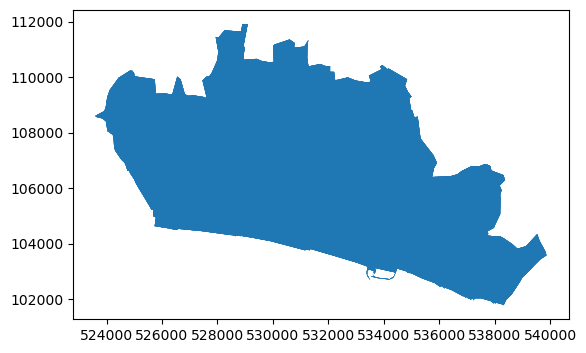

In [26]:
merged_data.plot()

In [ ]:
merged_data.explore()

In [ ]:
#Descriptive Analysis - DE
#before analysing my data I need to pivot the data in order to be able to analyse it:

In [ ]:
#pivoting the data


In [30]:
merged_data['Rlgn'].value_counts().get('Hindu', 0)

np.int64(562)

In [31]:
merged_data['Indst'].value_counts().get('F Construction')

np.int64(624)

KeyError: 'F Construction'

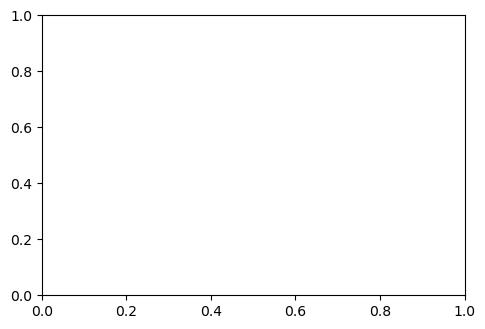

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

attributes_to_plot = ['F Construction',
                      '
                      'Male']

plt.figure(figsize=(12, 8))

for i, attribute in enumerate(attributes_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.violinplot(x=merged_data[attribute])
    plt.title(attribute)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

KeyError: 'Aged 25 to 34 years'

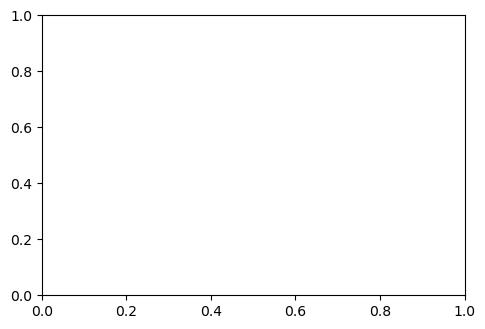

In [90]:
import matplotlib.pyplot as plt

attributes_to_plot = ['Aged 25 to 34 years',
                      'Economically active ...',
                      'F Construction',
                      'Male']

plt.figure(figsize=(12, 8))

for i, attribute in enumerate(attributes_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(merged_data[attribute].astype(str), kde=True)
    plt.title(attribute)

plt.tight_layout()
plt.show()